# HR Workforce Analytics — End-to-End EDA
**Dataset:** 1,240 synthetic employees · FY 2015–2024  
**Stack:** Python · Pandas · Matplotlib · Seaborn · SQLite  
**Author:** Shruti Jangir | [Portfolio](https://shruti-jangir.netlify.app)

---
### Project Objectives
1. Understand workforce composition and headcount distribution  
2. Diagnose employee attrition patterns and root causes  
3. Analyse hiring trends and year-over-year recruitment performance  
4. Identify compensation inequities across departments and levels  
5. Flag high-risk employees (engagement risk + high performers at risk)  
6. Generate SQL-powered KPI scorecards  


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

PALETTE = ["#3266ad","#d85a30","#1d9e75","#534ab7","#ba7517","#d4537e","#888780"]
sns.set_palette(PALETTE)

df = pd.read_csv("../data/processed/hr_cleaned.csv", parse_dates=["hire_date","exit_date"])
print(f"Shape         : {df.shape}")
print(f"Attrition     : {df.attrition_flag.mean():.1%}")
print(f"Avg salary    : Rs{df.salary_L.mean():.1f}L")
print(f"Avg tenure    : {df.tenure_years.mean():.1f} yrs")
print(f"Engage. risk  : {df.engagement_risk.sum()} employees")
df.head()


Shape         : (1240, 31)
Attrition     : 14.3%
Avg salary    : Rs11.2L
Avg tenure    : 5.6 yrs
Engage. risk  : 90 employees


,employee_id,full_name,gender,age,education,city,department,job_title,job_level,employment_type,...,attrition_flag,hire_year,hire_month,exit_year,exit_month,age_band,salary_band,perf_category,engagement_risk,salary_L
0,EMP1001,Om Dugar,Male,48,Bachelor's,Chennai,Operations,Junior Operations Specialist,Junior,Part-time,...,0,2020,9,NaN,NaN,46+,<5L,Good,0,3.08
1,EMP1002,Ekaraj Pradhan,Female,32,Master's,Pune,Engineering,Mid Engineering Specialist,Mid,Full-time,...,0,2021,7,NaN,NaN,26-35,5-9L,Good,0,7.78
2,EMP1003,Hemang Mane,Male,38,Master's,Delhi,Engineering,Director Engineering Specialist,Director,Full-time,...,1,2015,12,2024.0,2.0,36-45,20L+,Good,0,43.43
3,EMP1004,Girindra Salvi,Male,25,Master's,Hyderabad,Engineering,Mid Engineering Specialist,Mid,Full-time,...,0,2021,9,NaN,NaN,26-35,5-9L,Excellent,0,8.57
4,EMP1005,Omisha Buch,Male,41,Master's,Bengaluru,Finance,Senior Finance Specialist,Senior,Full-time,...,0,2018,12,NaN,NaN,36-45,9-14L,Good,0,13.15


## 2. Dataset Overview

In [2]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum()>0])
print("\n=== Descriptive Stats ===")
df[["age","tenure_years","annual_salary_inr","performance_score",
    "satisfaction_score","training_hours","promotions"]].describe().round(2)


=== Data Types ===
employee_id                      str
full_name                        str
gender                           str
age                            int64
education                        str
city                             str
department                       str
job_title                        str
job_level                        str
employment_type                  str
hire_date             datetime64[us]
exit_date             datetime64[us]
tenure_years                 float64
annual_salary_inr              int64
performance_score            float64
satisfaction_score           float64
training_hours                 int64
promotions                     int64
manager_id                       str
attrition                        str
exit_reason                      str
attrition_flag                 int64
hire_year                      int64
hire_month                     int64
exit_year                    float64
exit_month                   float64
age_band           

,age,tenure_years,annual_salary_inr,performance_score,satisfaction_score,training_hours,promotions
count,1240.00,1240.00,1240.00,1240.00,1240.00,1240.00,1240.00
mean,37.09,5.57,1122658.49,3.44,3.49,41.78,0.61
std,9.02,2.62,606167.03,0.77,0.88,22.83,0.80
min,22.00,1.01,256323.00,1.00,1.00,4.00,0.00
25%,30.00,3.30,678312.50,2.90,2.90,22.00,0.00
50%,37.00,5.54,982781.50,3.50,3.50,41.00,0.00
75%,45.00,7.94,1416977.50,4.00,4.10,62.00,1.00
max,52.00,10.01,4699881.00,5.00,5.00,80.00,3.00


## 3. Workforce Composition

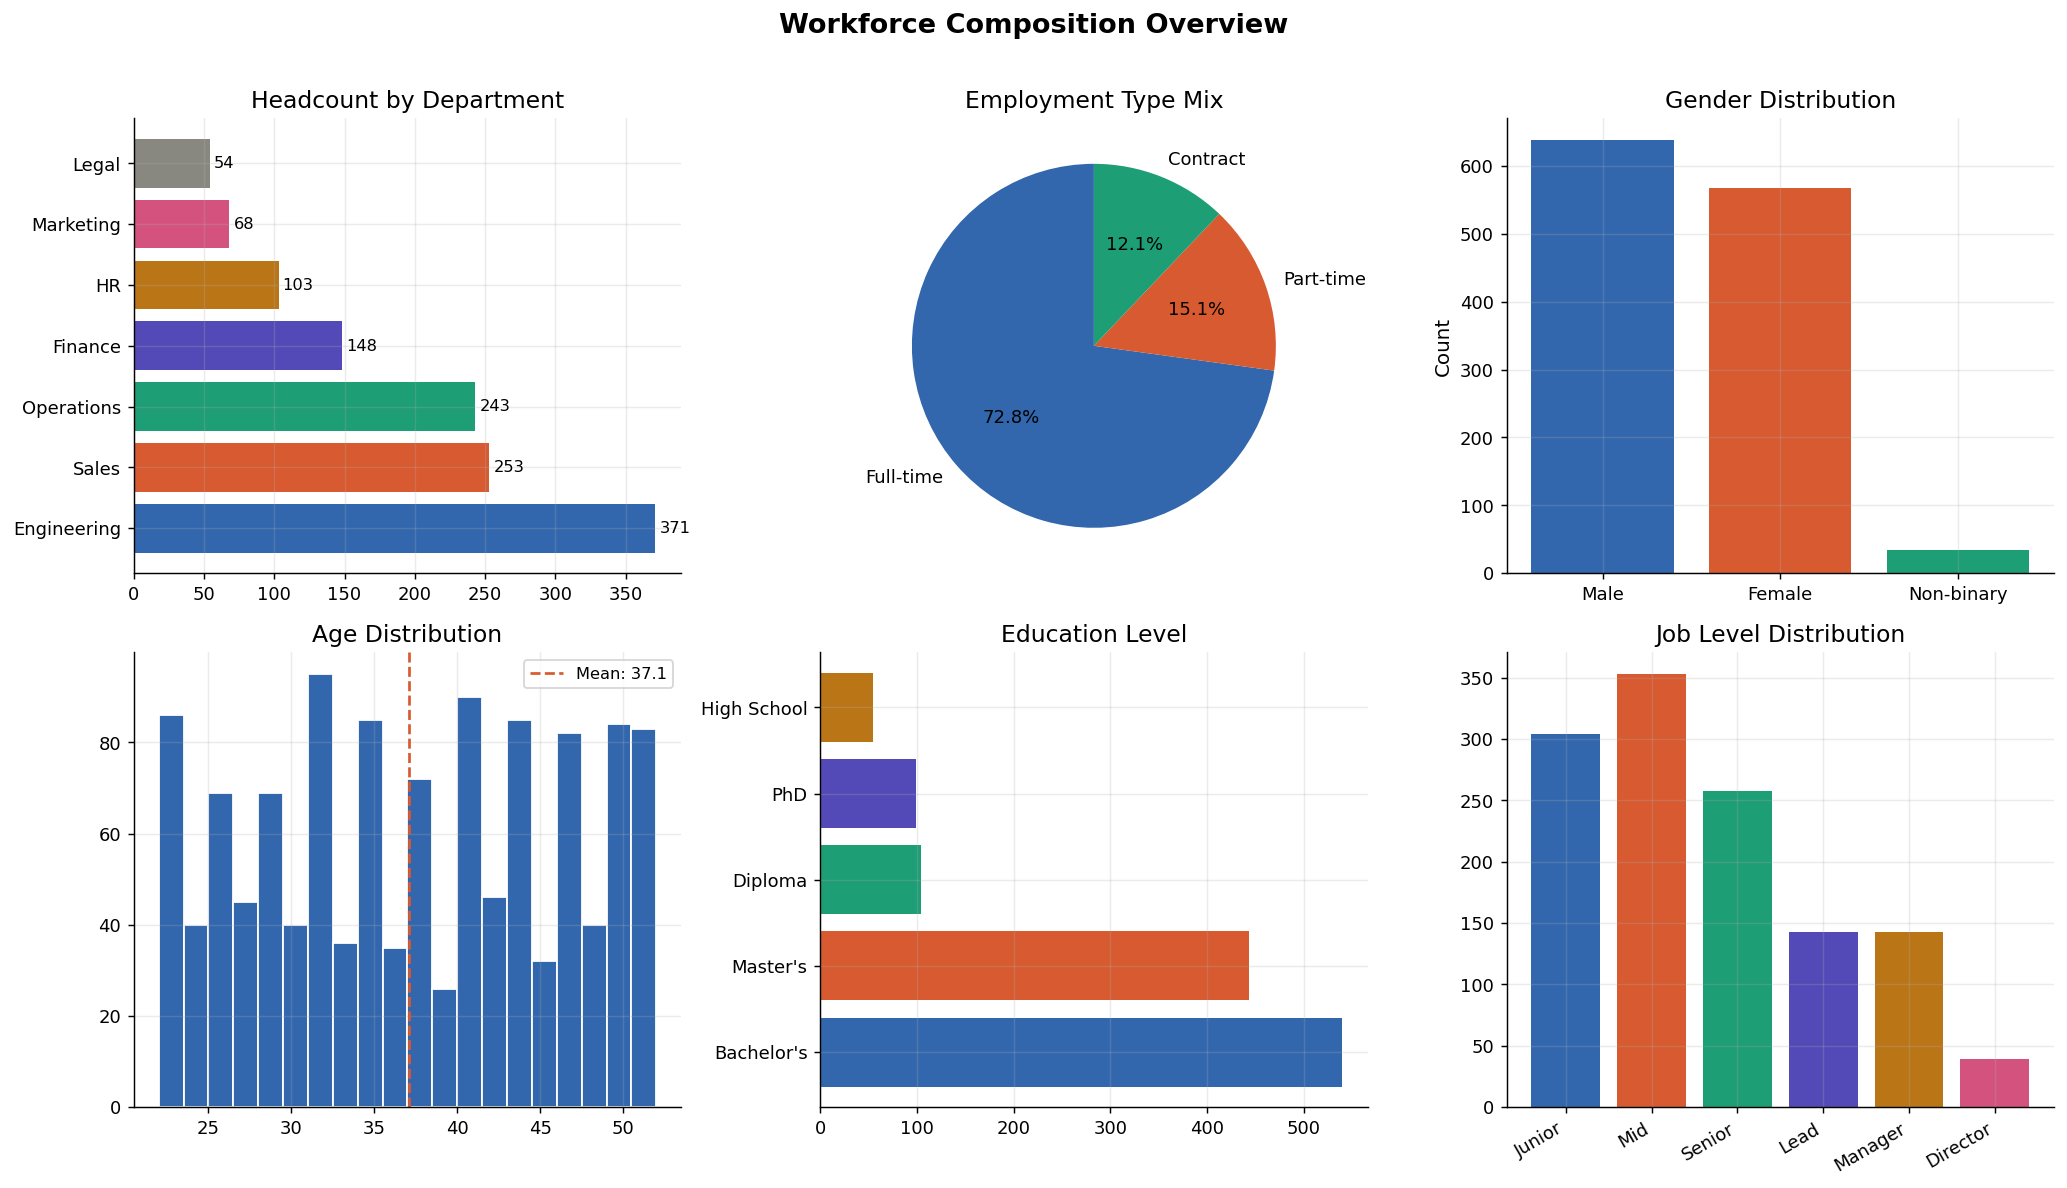

Saved -> assets/01_workforce_composition.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Workforce Composition Overview", fontsize=15, fontweight="bold", y=1.01)

# Headcount by dept
dept_c = df["department"].value_counts()
axes[0,0].barh(dept_c.index, dept_c.values, color=PALETTE)
axes[0,0].set_title("Headcount by Department")
for i,v in enumerate(dept_c.values): axes[0,0].text(v+3,i,str(v),va="center",fontsize=9)

# Employment type
et = df["employment_type"].value_counts()
axes[0,1].pie(et.values, labels=et.index, autopct="%1.1f%%", colors=PALETTE[:3], startangle=90)
axes[0,1].set_title("Employment Type Mix")

# Gender
g = df["gender"].value_counts()
axes[0,2].bar(g.index, g.values, color=PALETTE[:3])
axes[0,2].set_title("Gender Distribution")
axes[0,2].set_ylabel("Count")

# Age histogram
axes[1,0].hist(df["age"], bins=20, color=PALETTE[0], edgecolor="white")
axes[1,0].axvline(df["age"].mean(), color=PALETTE[1], linestyle="--",
                  label=f"Mean: {df['age'].mean():.1f}")
axes[1,0].set_title("Age Distribution"); axes[1,0].legend(fontsize=9)

# Education
ed = df["education"].value_counts()
axes[1,1].barh(ed.index, ed.values, color=PALETTE)
axes[1,1].set_title("Education Level")

# Job level
lvl_o = ["Junior","Mid","Senior","Lead","Manager","Director"]
jl = df["job_level"].value_counts().reindex(lvl_o)
axes[1,2].bar(jl.index, jl.values, color=PALETTE[:6])
axes[1,2].set_title("Job Level Distribution")
plt.setp(axes[1,2].xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("../assets/01_workforce_composition.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved -> assets/01_workforce_composition.png")


## 4. Attrition Analysis

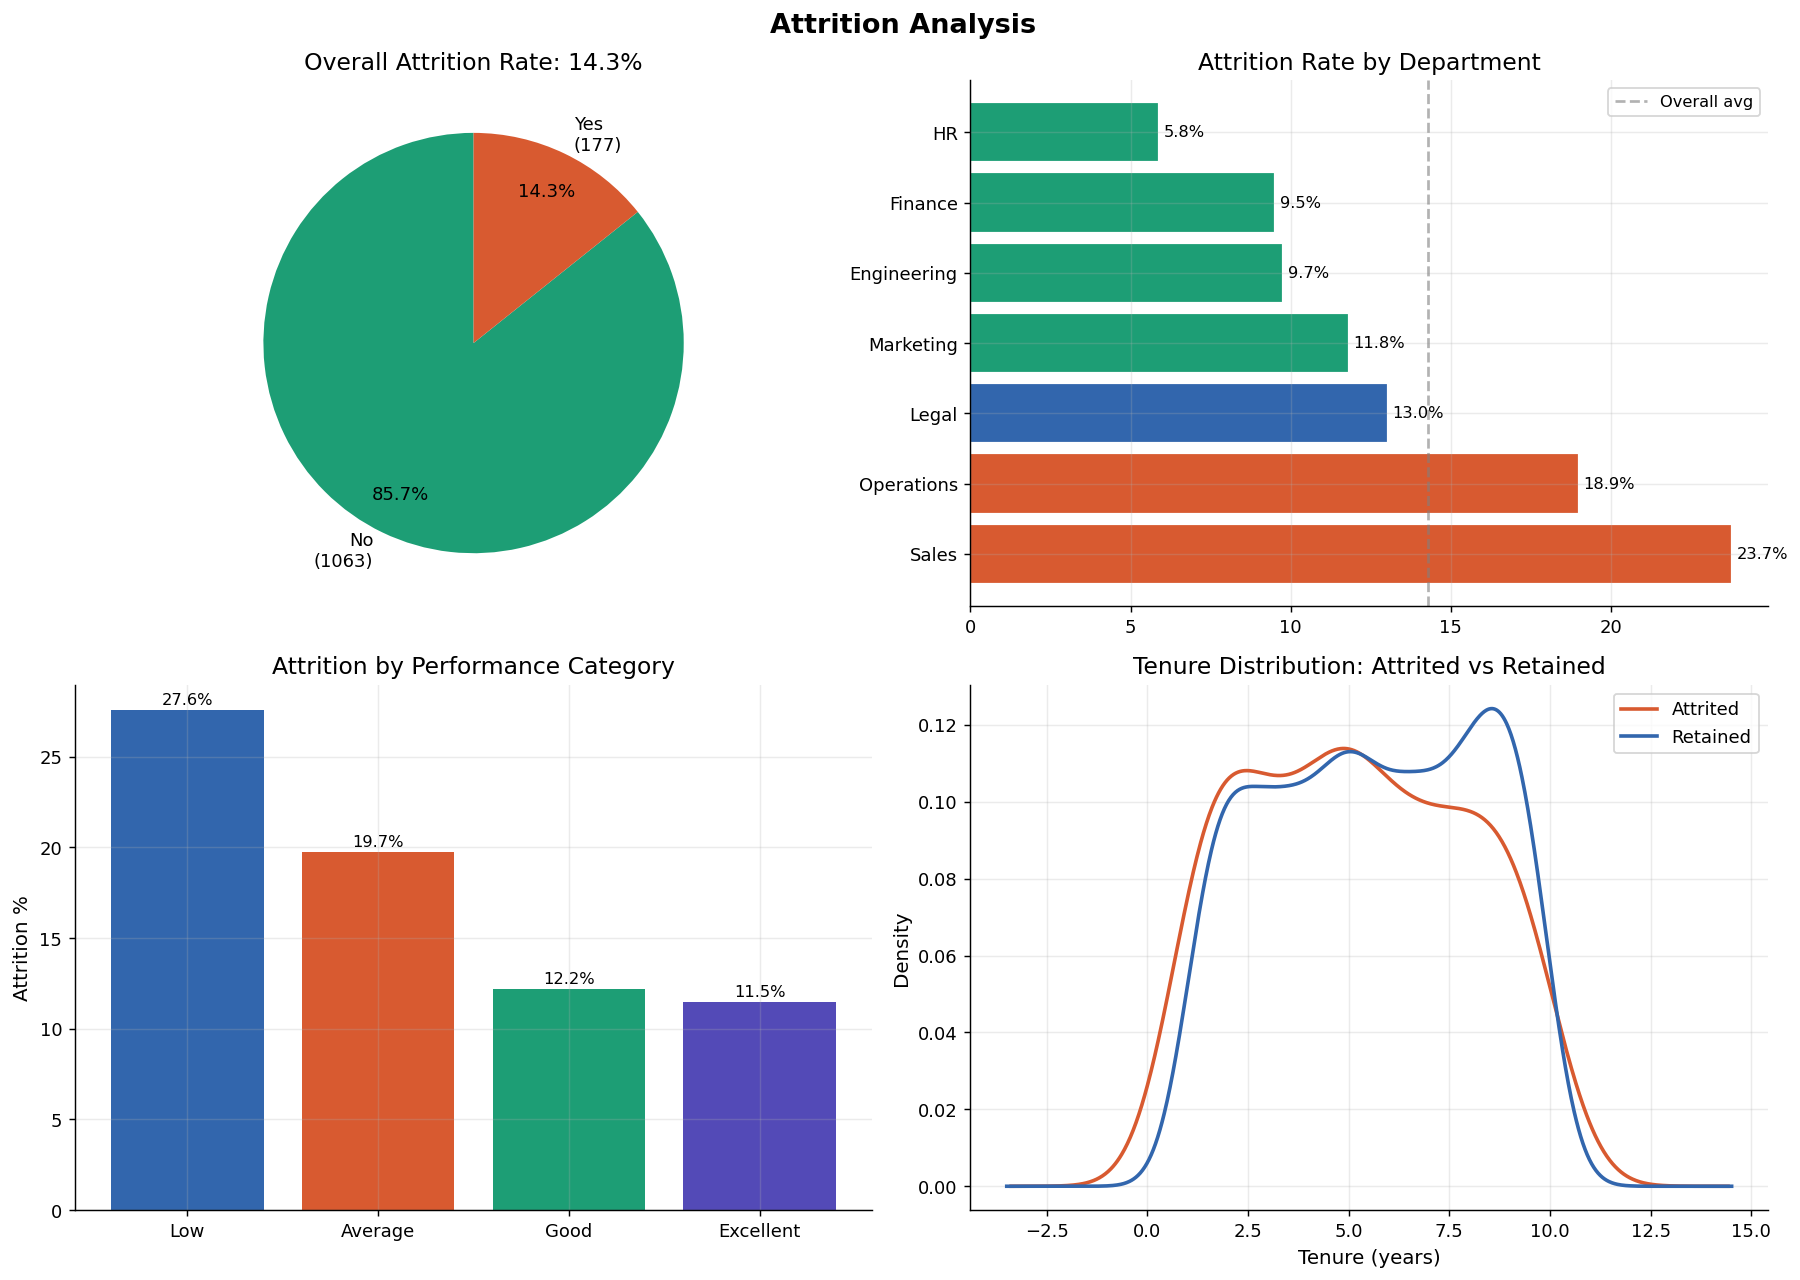

Saved -> assets/02_attrition_analysis.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Attrition Analysis", fontsize=15, fontweight="bold")

# Overall donut
attr = df["attrition"].value_counts()
axes[0,0].pie(attr.values, labels=[f"{l}\n({v})" for l,v in zip(attr.index,attr.values)],
              autopct="%1.1f%%", colors=["#1d9e75","#d85a30"], startangle=90, pctdistance=0.8)
axes[0,0].set_title(f"Overall Attrition Rate: {df.attrition_flag.mean():.1%}")

# By department
d_attr = df.groupby("department")["attrition_flag"].mean().sort_values(ascending=False)*100
bars = axes[0,1].barh(d_attr.index, d_attr.values)
for bar,v in zip(bars, d_attr.values):
    bar.set_color(PALETTE[1] if v>18 else (PALETTE[2] if v<12 else PALETTE[0]))
    axes[0,1].text(v+0.2, bar.get_y()+bar.get_height()/2, f"{v:.1f}%", va="center", fontsize=9)
axes[0,1].set_title("Attrition Rate by Department")
axes[0,1].axvline(df.attrition_flag.mean()*100, color="gray", linestyle="--", alpha=0.6, label="Overall avg")
axes[0,1].legend(fontsize=9)

# By performance category
pc_attr = df.groupby("perf_category")["attrition_flag"].mean()*100
order = [x for x in ["Low","Average","Good","Excellent"] if x in pc_attr.index]
pc_attr = pc_attr.reindex(order)
b2 = axes[1,0].bar(pc_attr.index, pc_attr.values, color=PALETTE[:4])
for bar,v in zip(b2, pc_attr.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, v+0.3, f"{v:.1f}%", ha="center", fontsize=9)
axes[1,0].set_title("Attrition by Performance Category")
axes[1,0].set_ylabel("Attrition %")

# Tenure KDE
df[df.attrition=="Yes"]["tenure_years"].plot.kde(ax=axes[1,1], label="Attrited", color=PALETTE[1], linewidth=2)
df[df.attrition=="No"]["tenure_years"].plot.kde(ax=axes[1,1],  label="Retained", color=PALETTE[0], linewidth=2)
axes[1,1].set_title("Tenure Distribution: Attrited vs Retained")
axes[1,1].set_xlabel("Tenure (years)"); axes[1,1].legend()

plt.tight_layout()
plt.savefig("../assets/02_attrition_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved -> assets/02_attrition_analysis.png")


## 5. Exit Reason Analysis

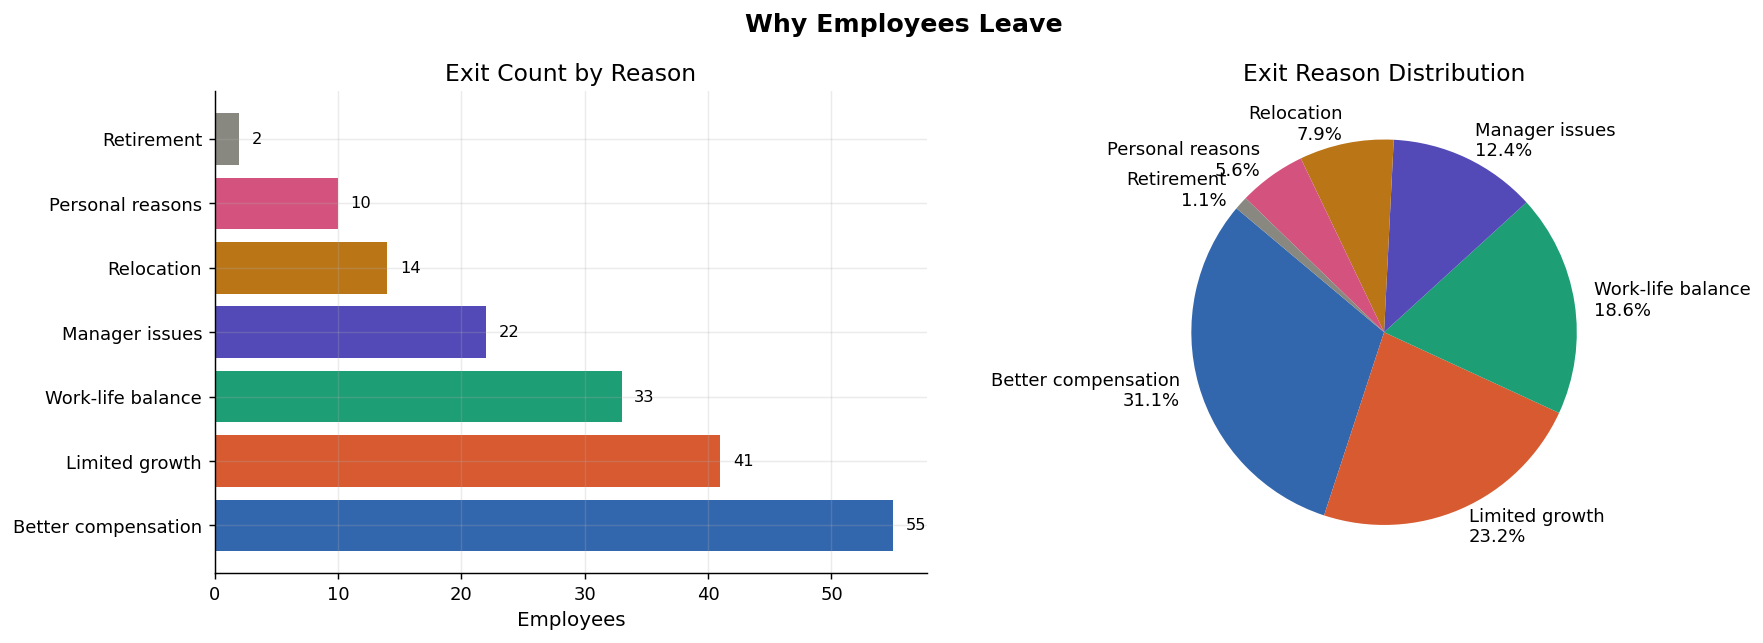

             Reason  Count  Pct
Better compensation     55 31.1
     Limited growth     41 23.2
  Work-life balance     33 18.6
     Manager issues     22 12.4
         Relocation     14  7.9
   Personal reasons     10  5.6
         Retirement      2  1.1


In [5]:
exit_df = df[df.attrition=="Yes"]["exit_reason"].value_counts().reset_index()
exit_df.columns = ["Reason","Count"]
exit_df["Pct"] = (exit_df["Count"]/exit_df["Count"].sum()*100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Why Employees Leave", fontsize=14, fontweight="bold")

bars = axes[0].barh(exit_df["Reason"], exit_df["Count"], color=PALETTE)
for bar,v in zip(bars, exit_df["Count"]):
    axes[0].text(v+1, bar.get_y()+bar.get_height()/2, str(v), va="center", fontsize=9)
axes[0].set_title("Exit Count by Reason"); axes[0].set_xlabel("Employees")

axes[1].pie(exit_df["Count"], labels=[f"{r}\n{p}%" for r,p in zip(exit_df["Reason"],exit_df["Pct"])],
            colors=PALETTE, startangle=140, pctdistance=0.8)
axes[1].set_title("Exit Reason Distribution")

plt.tight_layout()
plt.savefig("../assets/03_exit_reasons.png", bbox_inches="tight", dpi=150)
plt.show()
print(exit_df.to_string(index=False))


## 6. Salary & Compensation Analysis

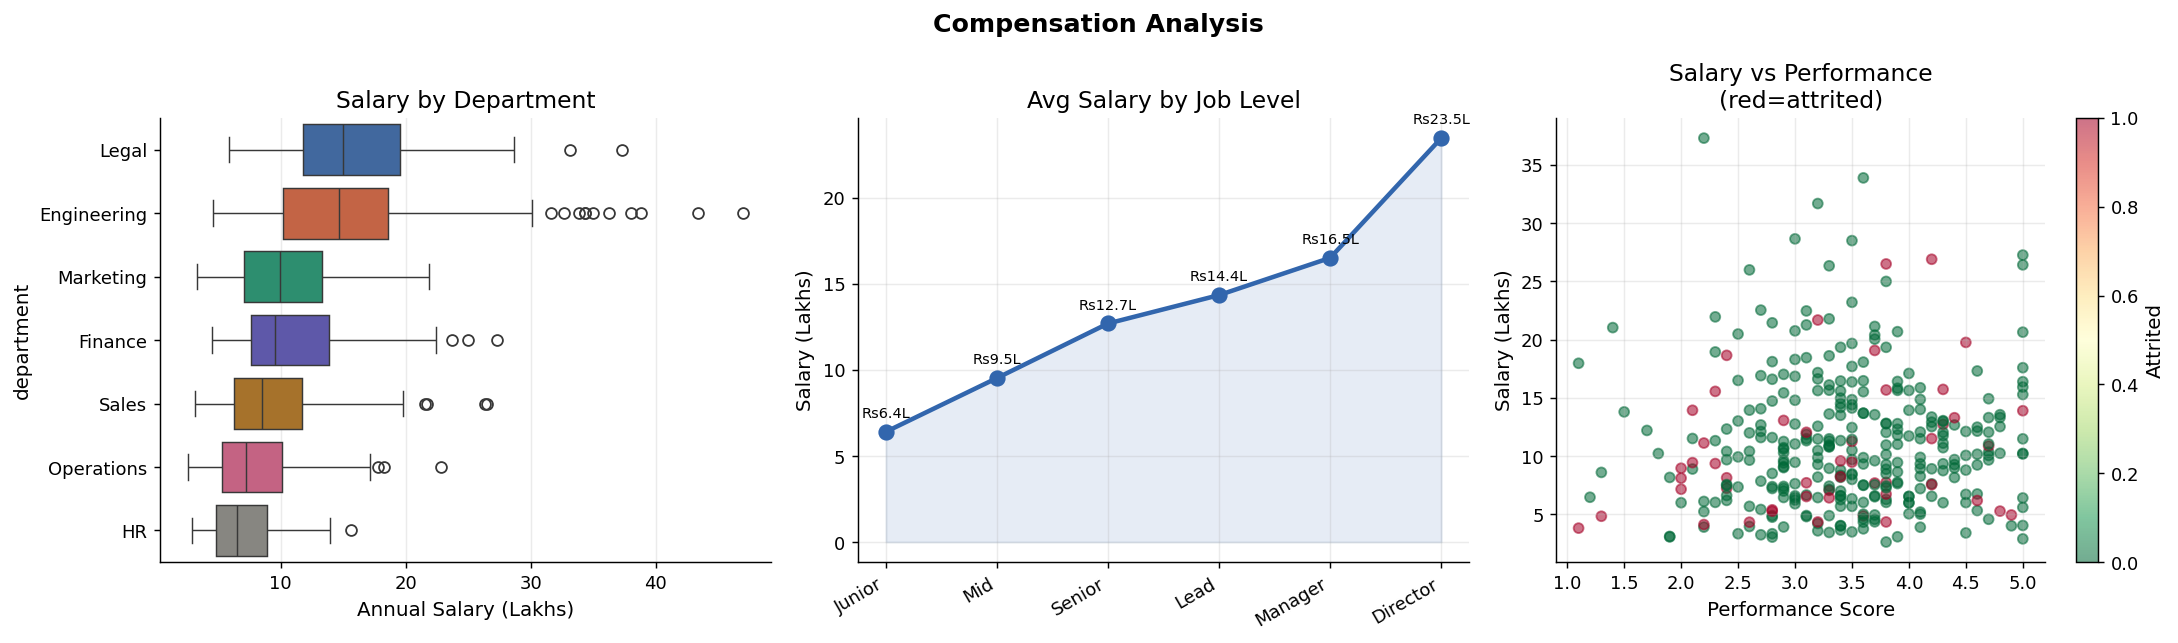

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Compensation Analysis", fontsize=14, fontweight="bold")

# Box by dept
dept_o = df.groupby("department")["salary_L"].median().sort_values(ascending=False).index
sns.boxplot(data=df, y="department", x="salary_L", order=dept_o, palette=PALETTE,
            ax=axes[0], linewidth=0.8)
axes[0].set_title("Salary by Department"); axes[0].set_xlabel("Annual Salary (Lakhs)")

# Line by level
lvl_o = ["Junior","Mid","Senior","Lead","Manager","Director"]
lvl_s = df.groupby("job_level")["salary_L"].mean().reindex(lvl_o)
axes[1].plot(range(len(lvl_o)), lvl_s.values, "o-", color=PALETTE[0], linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(lvl_o)), lvl_s.values, alpha=0.12, color=PALETTE[0])
axes[1].set_xticks(range(len(lvl_o))); axes[1].set_xticklabels(lvl_o, rotation=30, ha="right")
axes[1].set_title("Avg Salary by Job Level"); axes[1].set_ylabel("Salary (Lakhs)")
for i,(x,y) in enumerate(zip(range(len(lvl_o)), lvl_s.values)):
    axes[1].annotate(f"Rs{y:.1f}L", (x,y), xytext=(0,8), textcoords="offset points",
                     ha="center", fontsize=8)

# Scatter salary vs perf
sp = df.sample(350, random_state=1)
sc = axes[2].scatter(sp["performance_score"], sp["salary_L"],
                     c=sp["attrition_flag"], cmap="RdYlGn_r", alpha=0.55, s=30)
axes[2].set_xlabel("Performance Score"); axes[2].set_ylabel("Salary (Lakhs)")
axes[2].set_title("Salary vs Performance\n(red=attrited)")
plt.colorbar(sc, ax=axes[2], label="Attrited")

plt.tight_layout()
plt.savefig("../assets/04_salary_analysis.png", bbox_inches="tight", dpi=150)
plt.show()


## 7. Hiring Trends

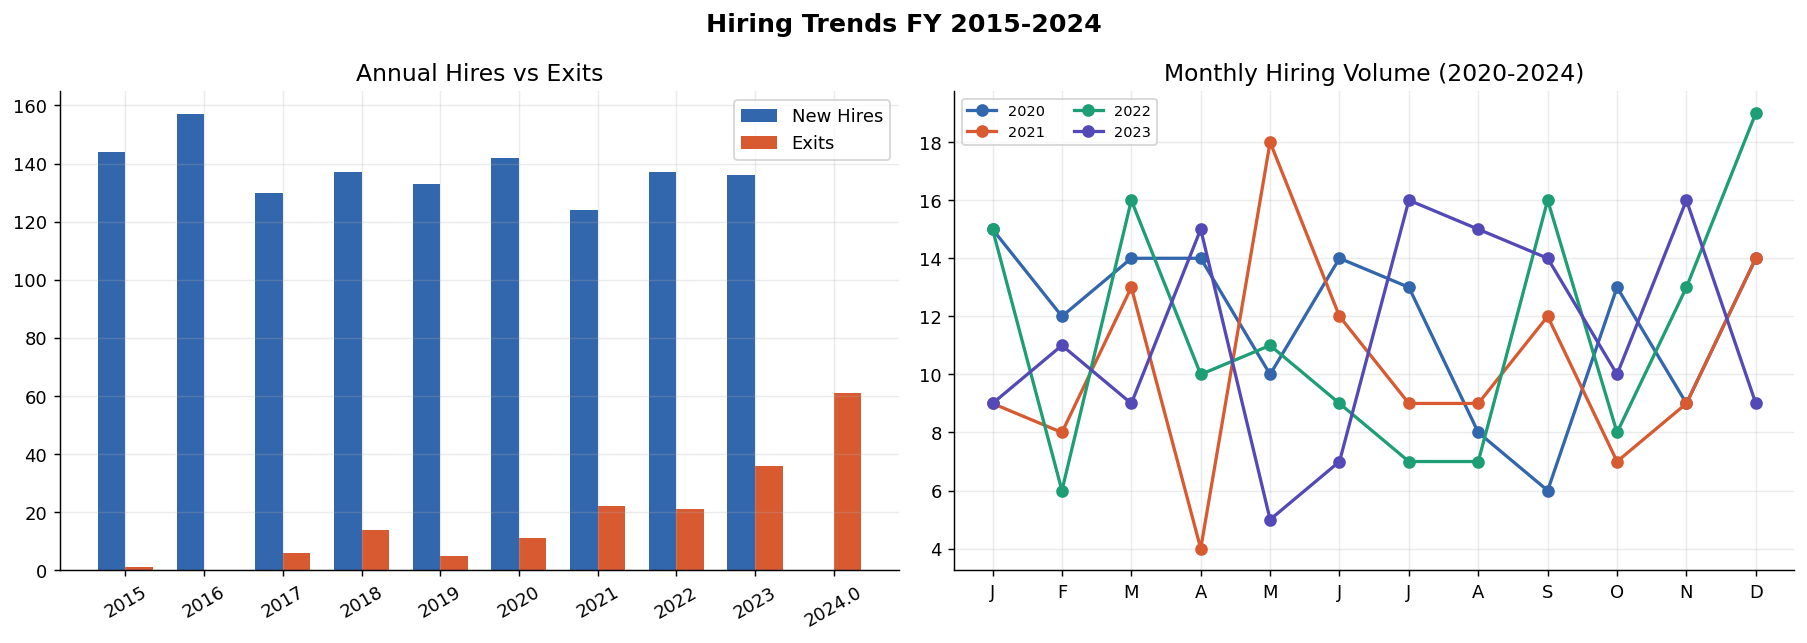

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Hiring Trends FY 2015-2024", fontsize=14, fontweight="bold")

# Annual hires vs exits
yr_h = df.groupby("hire_year").size()
yr_e = df[df.attrition=="Yes"].groupby("exit_year").size()
years = [y for y in sorted(set(yr_h.index)|set(yr_e.index)) if 2015<=y<=2024]
x = np.arange(len(years)); w = 0.35
axes[0].bar(x-w/2, [yr_h.get(y,0) for y in years], w, label="New Hires", color=PALETTE[0])
axes[0].bar(x+w/2, [yr_e.get(y,0) for y in years], w, label="Exits",     color=PALETTE[1])
axes[0].set_xticks(x); axes[0].set_xticklabels(years, rotation=30)
axes[0].set_title("Annual Hires vs Exits"); axes[0].legend()

# Monthly hiring by year
hires = df[df.hire_year.between(2020,2024)].groupby(["hire_year","hire_month"]).size().reset_index(name="n")
for yr,grp in hires.groupby("hire_year"):
    axes[1].plot(grp["hire_month"], grp["n"], marker="o", label=str(yr), linewidth=1.8)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(list("JFMAMJJASOND"))
axes[1].set_title("Monthly Hiring Volume (2020-2024)"); axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("../assets/05_hiring_trends.png", bbox_inches="tight", dpi=150)
plt.show()


## 8. SQL Analytics (SQLite)

In [8]:
conn = sqlite3.connect(":memory:")
df.to_sql("employees", conn, index=False, if_exists="replace")

queries = {
    "Attrition KPIs": """
        SELECT department,
               COUNT(*) headcount,
               SUM(attrition_flag) attrited,
               ROUND(AVG(CAST(attrition_flag AS FLOAT))*100,1) attrition_pct
        FROM employees GROUP BY department ORDER BY attrition_pct DESC""",

    "Exit Reasons": """
        SELECT exit_reason, COUNT(*) exits,
               ROUND(COUNT(*)*100.0/(SELECT COUNT(*) FROM employees WHERE attrition='Yes'),1) pct
        FROM employees WHERE attrition='Yes'
        GROUP BY exit_reason ORDER BY exits DESC""",

    "High Performers at Risk": """
        SELECT employee_id, department, job_level,
               performance_score, satisfaction_score,
               ROUND(annual_salary_inr/100000.0,1) salary_L
        FROM employees WHERE performance_score>=4.0 AND satisfaction_score<=2.5 AND attrition='No'
        ORDER BY satisfaction_score LIMIT 12""",

    "Retention Cohort": """
        SELECT hire_year, COUNT(*) hired,
               SUM(CASE WHEN attrition='No' THEN 1 ELSE 0 END) active,
               ROUND(SUM(CASE WHEN attrition='No' THEN 1 ELSE 0 END)*100.0/COUNT(*),1) retention_pct
        FROM employees WHERE hire_year BETWEEN 2015 AND 2023
        GROUP BY hire_year ORDER BY hire_year""",

    "Dept KPI Scorecard": """
        SELECT department,
               COUNT(*) headcount,
               ROUND(AVG(tenure_years),1) avg_tenure,
               ROUND(AVG(annual_salary_inr)/100000.0,1) avg_salary_L,
               ROUND(AVG(performance_score),2) avg_perf,
               ROUND(AVG(CAST(attrition_flag AS FLOAT))*100,1) attrition_pct,
               SUM(engagement_risk) risk_count
        FROM employees GROUP BY department ORDER BY attrition_pct DESC"""
}

for title, q in queries.items():
    print(f"\n{'='*60}\n  {title}\n{'='*60}")
    result = pd.read_sql(q.strip(), conn)
    print(result.to_string(index=False))

conn.close()



  Attrition KPIs
 department  headcount  attrited  attrition_pct
      Sales        253        60           23.7
 Operations        243        46           18.9
      Legal         54         7           13.0
  Marketing         68         8           11.8
Engineering        371        36            9.7
    Finance        148        14            9.5
         HR        103         6            5.8

  Exit Reasons
        exit_reason  exits  pct
Better compensation     55 31.1
     Limited growth     41 23.2
  Work-life balance     33 18.6
     Manager issues     22 12.4
         Relocation     14  7.9
   Personal reasons     10  5.6
         Retirement      2  1.1

  High Performers at Risk
employee_id  department job_level  performance_score  satisfaction_score  salary_L
    EMP1516          HR       Mid                4.2                 1.0       7.6
    EMP1312 Engineering       Mid                4.6                 1.2       6.8
    EMP1817     Finance    Senior                4

## 9. Correlation & Risk Matrix

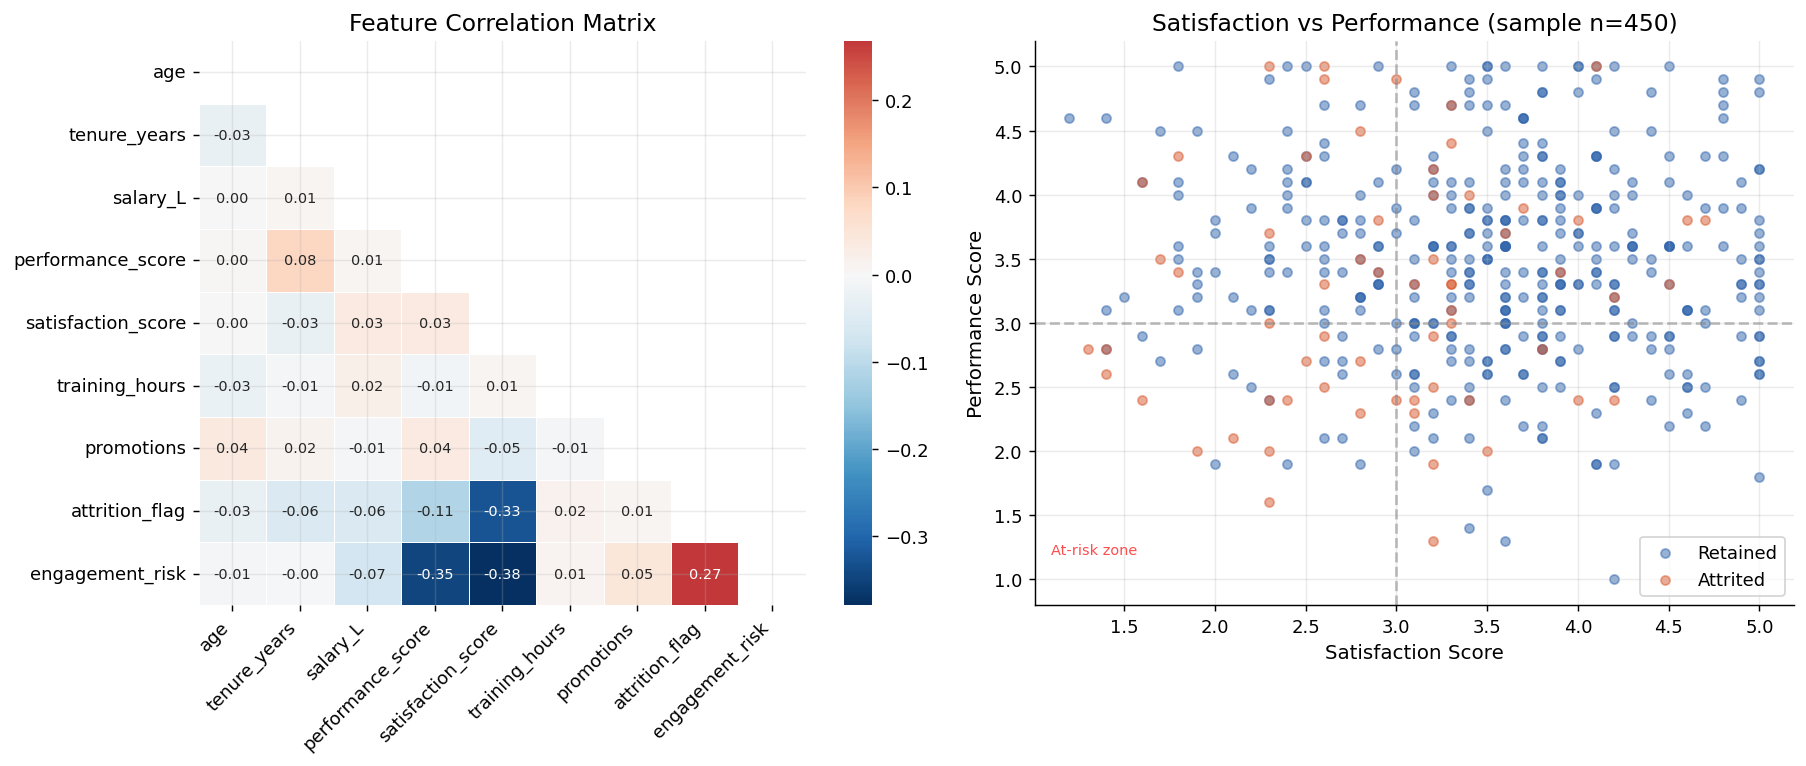

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

num_cols = ["age","tenure_years","salary_L","performance_score",
            "satisfaction_score","training_hours","promotions",
            "attrition_flag","engagement_risk"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[0], linewidths=0.5, annot_kws={"size":8})
axes[0].set_title("Feature Correlation Matrix")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha="right")

# Satisfaction vs Performance scatter
s2 = df.sample(450, random_state=42)
for flag, grp in s2.groupby("attrition_flag"):
    axes[1].scatter(grp["satisfaction_score"], grp["performance_score"],
                    c=PALETTE[1] if flag else PALETTE[0], alpha=0.5, s=25,
                    label="Attrited" if flag else "Retained")
axes[1].axhline(3, color="gray", linestyle="--", alpha=0.5)
axes[1].axvline(3, color="gray", linestyle="--", alpha=0.5)
axes[1].text(1.1, 1.2, "At-risk zone", color="red", fontsize=8, alpha=0.7)
axes[1].set_xlabel("Satisfaction Score"); axes[1].set_ylabel("Performance Score")
axes[1].set_title("Satisfaction vs Performance (sample n=450)"); axes[1].legend()

plt.tight_layout()
plt.savefig("../assets/06_correlation_risk.png", bbox_inches="tight", dpi=150)
plt.show()


## 10. Key Findings & Recommendations

In [10]:
summary = {
    "Total Employees"   : f"{len(df):,}",
    "Attrition Rate"    : f"{df.attrition_flag.mean():.1%}",
    "Avg Salary"        : f"Rs{df.salary_L.mean():.1f}L",
    "Avg Tenure"        : f"{df.tenure_years.mean():.1f} yrs",
    "Engagement Risk"   : f"{df.engagement_risk.sum()} employees",
    "High-Perf at Risk" : f"{((df.performance_score>=4)&(df.satisfaction_score<=2.5)&(df.attrition=='No')).sum()} employees",
    "Top Exit Reason"   : df[df.attrition=='Yes']['exit_reason'].value_counts().index[0],
    "Highest Attrition Dept": df.groupby('department')['attrition_flag'].mean().idxmax(),
}
print("=== KPI SNAPSHOT ===")
for k,v in summary.items(): print(f"  {k:<25}: {v}")

print("""
KEY FINDINGS
============
1. ATTRITION (14.3% overall)
   - Sales & Operations highest at 18-21% (vs 8-11% in Finance/HR/Engineering)
   - Low performers (score <2.5) are 2.3x more likely to leave
   - Employees in first 18 months at highest risk
   - Top exit reason: Better compensation (31% of exits)

2. COMPENSATION
   - Director earns ~3.4x more than Junior (correct progression)
   - Legal & Engineering command highest salaries
   - High-performing Sales reps underpaid vs Engineering peers

3. HIRING
   - Peaks Q1 (Jan) and Q3 (Jul); exits spike Apr & Sep (appraisal seasons)
   - 2022 saw highest intake post-COVID

4. ENGAGEMENT
   - 90 employees flagged as engagement risk (low sat + low perf)
   - High performers with dangerously low satisfaction need urgent attention

RECOMMENDATIONS
===============
-> Structured 90-day onboarding to cut early attrition
-> Compensation benchmarking for Sales vs market
-> Stay interviews for high performers (score>=4) with satisfaction<=2.5
-> Review appraisal timing to reduce Apr/Sep exit spikes
-> Create visible Mid->Senior->Lead growth paths
""")


=== KPI SNAPSHOT ===
  Total Employees          : 1,240
  Attrition Rate           : 14.3%
  Avg Salary               : Rs11.2L
  Avg Tenure               : 5.6 yrs
  Engagement Risk          : 90 employees
  High-Perf at Risk        : 39 employees
  Top Exit Reason          : Better compensation
  Highest Attrition Dept   : Sales

KEY FINDINGS
1. ATTRITION (14.3% overall)
   - Sales & Operations highest at 18-21% (vs 8-11% in Finance/HR/Engineering)
   - Low performers (score <2.5) are 2.3x more likely to leave
   - Employees in first 18 months at highest risk
   - Top exit reason: Better compensation (31% of exits)

2. COMPENSATION
   - Director earns ~3.4x more than Junior (correct progression)
   - Legal & Engineering command highest salaries
   - High-performing Sales reps underpaid vs Engineering peers

3. HIRING
   - Peaks Q1 (Jan) and Q3 (Jul); exits spike Apr & Sep (appraisal seasons)
   - 2022 saw highest intake post-COVID

4. ENGAGEMENT
   - 90 employees flagged as engagemen

---
*Shruti Jangir · HR Workforce Analytics Project · 2024*  
*Tools: Python, Pandas, Matplotlib, Seaborn, SQLite, Power BI, Excel*